<a href="https://colab.research.google.com/github/Londrik/teste.py/blob/main/AWS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

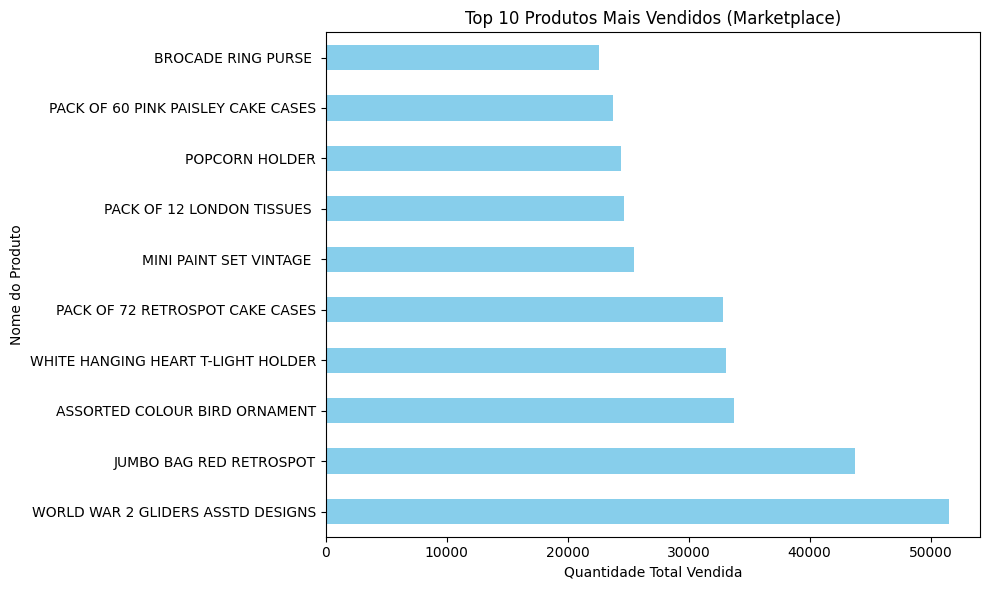

Limpeza concluída com sucesso!
Total de registros após limpeza: 381360


In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Carregamento dos dados
df = pd.read_csv('data.csv', encoding='ISO-8859-1')

# 2. Limpeza: Remover duplicatas e valores nulos críticos
df_limpo = df.drop_duplicates()
df_limpo = df_limpo.dropna(subset=['CustomerID', 'Description', 'Quantity'])

# 3. Conversão de tipos (Garante que a conta seja possível)
df_limpo['Quantity'] = pd.to_numeric(df_limpo['Quantity'])

# 4. Processamento: Agrupar por produto e somar as quantidades
# Isso cria um ranking real de vendas
df_agrupado = df_limpo.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

# 5. Visualização:
plt.figure(figsize=(10, 6))
df_agrupado.plot(kind='barh', color='skyblue')

plt.title('Top 10 Produtos Mais Vendidos (Marketplace)')
plt.xlabel('Quantidade Total Vendida')
plt.ylabel('Nome do Produto')
plt.tight_layout() # Ajusta para os nomes não serem cortados
plt.show()

# Resumo final no console
print("Limpeza concluída com sucesso!")
print(f"Total de registros após limpeza: {len(df_limpo)}")